In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv


In [45]:
import numpy
import pandas as pd
import gc

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully')


Libraries imported successfully


## Step 1: Load the Data

The competition provides several files:
* `train.csv`: data, store_nbr, family, sales, onpromotion(`starget=sales`)
* `test.csv`: same columns minus `sales`( this is what we predict)
* `stores.csv`: store metadata(city, state, type, cluster)
* `oil.csv`: daily oil price(Ecuador is oil-dependent, so this affects the economy)
* `holidays_events.csv`: holidays/events, which affect shopping behavior
* `transactions.csv`: daily transactions per store (extra signal, train period only)
* `sample_submission.csv`: shows the exact submission format required

In [46]:
import os 
import pandas as pd
import kagglehub

print("Downloading competition files...")
competition_path=kagglehub.competition_download('store-sales-time-series-forecasting')
print("Path to competition files:", competition_path)

# 2.Define the path pointing to the downloaded kagglehub folder
# Using os.path.join ensuring the trailing slash / directionary matching is correct
path=competition_path + '/'

# 3.Read the datasets using your exact variables and date parsing
train=pd.read_csv(path+'train.csv', parse_dates=['date'])
test=pd.read_csv(path+'test.csv', parse_dates=['date'])
stores=pd.read_csv(path+'stores.csv')
oil = pd.read_csv(path + 'oil.csv', parse_dates=['date'])
holidays = pd.read_csv(path + 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(path + 'transactions.csv', parse_dates=['date'])
sample_submission = pd.read_csv(path + 'sample_submission.csv')

#4. Print dataset shapes and verify data
print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)
print("Stores shape:", stores.shape)
print("Oil shape:", oil.shape)
print("Holidays shape:", holidays.shape)
print("Transactions shape:", transactions.shape)

print("\nFirst 5 rows of Train data:")
display(train.head())


Path to competition files: /kaggle/input/competitions/store-sales-time-series-forecasting

Train shape: (3000888, 6)
Test shape: (28512, 5)
Stores shape: (54, 5)
Oil shape: (1218, 2)
Holidays shape: (350, 6)
Transactions shape: (83488, 3)

First 5 rows of Train data:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## Step 2: Quick Look at the Data
lets check dathe date range, look for missing values, and see a quick sales trend so we understand whta we are working with.

Train date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Test date range: 2017-08-16 00:00:00 to 2017-08-31 00:00:00

Missing values in train:
 id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Unique families: 33
Unique stores: 54


<Axes: title={'center': 'Total Daily Sales Across All Stores'}, xlabel='date'>

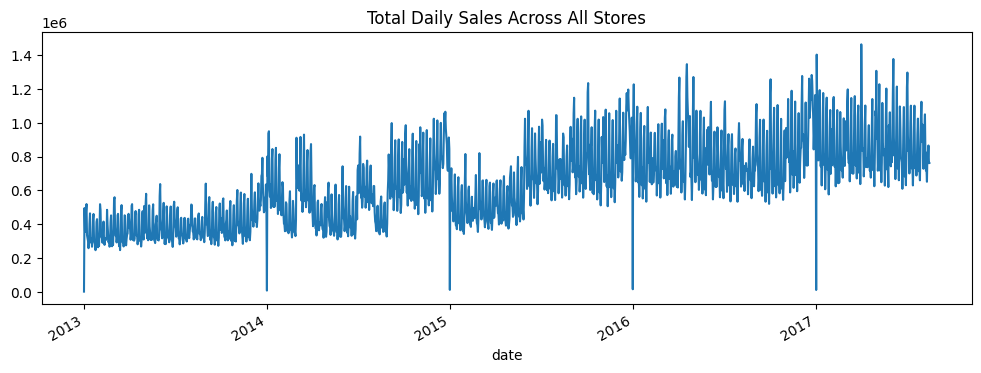

In [47]:
print("Train date range:", train['date'].min(), "to", train['date'].max())
print("Test date range:", test['date'].min(), "to", test['date'].max())
print("\nMissing values in train:\n", train.isnull().sum())
print("\nUnique families:", train['family'].nunique())
print("Unique stores:", train['store_nbr'].nunique())

#Overall daily sales trend
daily_sales=train.groupby('date')['sales'].sum()
daily_sales.plot(figsize=(12,4), title='Total Daily Sales Across All Stores')

## Step 3: Merge in Store, Oil, and Holiday Data

We combine everything into one table so the model can use all available signals:
* Merge `stores.csv` on `store_nbr`(adds city, state, type, cluster)
* Merge `oil.csv` on `date`(fill missing days by forward/backward fill, since iol prices arenot reported on weekends/holidays)
* Merge a simplied holiday flag from `holidays_events.csv` on `date`
We combine train and test temporarily so both get identical feature engineering, then split them back apart afterward.

In [48]:
# Mark which rows are train vs test, then stack them toogether

train['is_train']=1
test['is_train']=0
test['sales']=np.nan

#Merge store metadata
full=pd.concat([train, test], axis=0, ignore_index=True)
#Merge store metadata
full=full.merge(stores, on='store_nbr', how='left')


#Fill oil price gaps, then merge
oil=oil.set_index('date').asfreq('D') #Ensure every calendar day exists
oil['dcoilwtico']=oil['dcoilwtico'].ffill().bfill()
oil=oil.reset_index()
full=full.merge(oil, on='date', how='left')


#Simplify holidays: 1 if that date is a national, non-transferred holiday
national_holidays=holidays[(holidays['locale']=='National') & (holidays['transferred']==False)][['date']].drop_duplicates()
national_holidays['is_holiday']=1
full=full.merge(national_holidays,on='date', how='left')
full['is_holiday']=full['is_holiday'].fillna(0).astype(int)
print(full)
print("Merged shape:", full.shape)
full.head()

del train, test, oil, holidays, national_holidays
gc.collect()

              id       date  store_nbr                      family  sales  \
0              0 2013-01-01          1                  AUTOMOTIVE    0.0   
1              1 2013-01-01          1                   BABY CARE    0.0   
2              2 2013-01-01          1                      BEAUTY    0.0   
3              3 2013-01-01          1                   BEVERAGES    0.0   
4              4 2013-01-01          1                       BOOKS    0.0   
...          ...        ...        ...                         ...    ...   
3029395  3029395 2017-08-31          9                     POULTRY    NaN   
3029396  3029396 2017-08-31          9              PREPARED FOODS    NaN   
3029397  3029397 2017-08-31          9                     PRODUCE    NaN   
3029398  3029398 2017-08-31          9  SCHOOL AND OFFICE SUPPLIES    NaN   
3029399  3029399 2017-08-31          9                     SEAFOOD    NaN   

         onpromotion  is_train   city      state type  cluster  dcoilwtico 

424

## Step 4: Feature Engineering
We extract useful dste parts(year, month, day, day of week, week of year), since sales have strong weekly and seasonal patterns. We also flag weekends, which typically see different shopping behavior that weekdays.

In [17]:
full['year']=full['date'].dt.year
full['month']=full['date'].dt.month
full['day']=full['date'].dt.day
full['dayofweek']=full['date'].dt.dayofweek
full['weekofyear']=full['date'].dt.isocalendar().week.astype(int)
full['is_weekend']=(full['dayofweek'] >= 5).astype(int)

#Fill any remaining gaps in promotion count
full['onpromotion']=full['onpromotion'].fillna(0)

print("Feature engineering done")
full[['date', 'year', 'month', 'day', 'dayofweek',  'weekofyear', 'is_weekend']].head()

Feature engineering done


,date,year,month,day,dayofweek,weekofyear,is_weekend
0,2013-01-01,2013,1,1,1,1,0
1,2013-01-01,2013,1,1,1,1,0
2,2013-01-01,2013,1,1,1,1,0
3,2013-01-01,2013,1,1,1,1,0
4,2013-01-01,2013,1,1,1,1,0


## Step 5: Encode Categorical Columns
Machine learning models need numbers, not text, so we label-encode the categorical columns: family (product category), city, state, and store `type`.

In [18]:
categorical_cols=['family', 'city', 'state', 'type']

encoders = {}
for col in categorical_cols:
    le=LabelEncoder()
    full[col]=le.fit_transform(full[col].astype(str))
    encoders[col]=le

print("Categoorical columns encoded:", categorical_cols)
full[categorical_cols].head()

Categoorical columns encoded: ['family', 'city', 'state', 'type']


,family,city,state,type
0,0,18,12,3
1,1,18,12,3
2,2,18,12,3
3,3,18,12,3
4,4,18,12,3


## Step 6: Split Back into Train and Test

Now that both sets share the same feature, we split them apart again using the `is_train` flag we created earlier.

We also apply `log1p` to the sales tartget. The competition is scored with RMSLE(Root Mean Squared Log Error), so training directly on log-sales makes our simple RMSE-based model optimize the right thing.

In [19]:
feature_cols = [
    'store_nbr', 'family', 'onpromotion', 'city', 'state', 'type', 'cluster',
    'dcoilwtico', 'is_holiday', 'year', 'month', 'day', 'dayofweek',
    'weekofyear', 'is_weekend'
]

train_full=full[full['is_train']==1].copy()
test_full=full[full['is_train']==0].copy()

train_full['sales_log']=np.log1p(train_full['sales'])

del full
gc.collect()
print("Train_full shape:", train_full.shape)
print("Test_full shape:", test_full.shape)

Train_full shape: (3000888, 20)
Test_full shape: (28512, 19)


## Step 7: Time-based Train/Validation Split

For time series, we never randomly shuffle train/validation - that would leak future information into training. Insted, we hold out the last 16 days of the training period as validation, matching the test set's forecast horizon.

In [20]:
train_full = train_full.sort_values('date')
cutoff_date = train_full['date'].max() - pd.Timedelta(days=16)

train_split = train_full[train_full['date'] <= cutoff_date]
val_split = train_full[train_full['date'] > cutoff_date]

X_train, y_train=train_split[feature_cols],train_split['sales_log']
X_val, y_val=val_split[feature_cols], val_split['sales_log']

print("Train split:", X_train.shape)
print("Validation split:", X_val.shape)

Train split: (2972376, 15)
Validation split: (28512, 15)


## Step 8: Train LightGBM Model
LightGBM is a fast, tree/based gradient boosting model that handels this kind od tabular data well and train quickly even on millions of rows - a good fit for a beginner-friendly, quuck to run baseline

In [24]:
import lightgbm as lgb
categorical_features = ['store_nbr', 'family', 'city', 'state', 'type', 'cluster']

lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)
lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=categorical_features, reference=lgb_train)
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'verbose': -1,
    'seed': 42
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=50)]
)

gc.collect()

Training until validation scores don't improve for 30 rounds
[50]	train's rmse: 0.726851	valid's rmse: 0.68667
[100]	train's rmse: 0.578971	valid's rmse: 0.60869
[150]	train's rmse: 0.523858	valid's rmse: 0.545766
[200]	train's rmse: 0.494537	valid's rmse: 0.498549
[250]	train's rmse: 0.475807	valid's rmse: 0.479218
[300]	train's rmse: 0.465488	valid's rmse: 0.470514
[350]	train's rmse: 0.454008	valid's rmse: 0.466267
[400]	train's rmse: 0.445624	valid's rmse: 0.460748
[450]	train's rmse: 0.437789	valid's rmse: 0.457275
[500]	train's rmse: 0.430687	valid's rmse: 0.453312
Did not meet early stopping. Best iteration is:
[497]	train's rmse: 0.431202	valid's rmse: 0.453293


642

## Step 9: Evaluate on the Validation Set
We convert predictions back from loh-scale using `expm1`, clip any negative values to 0(sales cant be negative), and compute RMSLE to see how will we are doing on unseen(future) days.

In [25]:
val_preds_log=model.predict(X_val, num_iteration=model.best_iteration)
val_preds = np.expm1(val_preds_log)
val_preds = np.clip(val_preds, 0, None)

val_actual = np.expm1(y_val)

rmsle = np.sqrt(mean_squared_log_error(val_actual, valinkcode
Step 10: Predict on the Test Set¶
Now we use the trained model to forecast sales for every row in test.csv.l_preds))
print(f"Validation RMSLE: {rmsle:.4f}")

del val_preds_log, val_preds, val_actual
gc.collect()

Validation RMSLE: 0.4533


4

## Step 10: Predict on the test set

Now we use the trained model to forecast sales for every row in `test.csv`.


In [27]:
X_test = test_full[feature_cols]

test_preds_log = model.predict(X_test, num_iteration=model.best_iteration)
test_preds = np.expm1(test_preds_log)
test_preds = np.clip(test_preds, 0, None)

print("Predictions generated for", len(test_preds), "rows.")
print("Sample predictions:", test_preds[:10])

gc.collect()

Predictions generated for 28512 rows.
Sample predictions: [3.52188783e+00 9.02584074e-02 5.72416956e+00 2.32530700e+03
 9.52809129e-02 4.22707300e+02 1.23225829e+01 7.45352996e+02
 8.10255406e+02 1.59637666e+02]


226

## Step 11: Create the Submission File

The competition requires a CSV with exactly two columns:
* `id`: matches the `id` from `test.csv`.
* `sales`: the predicted sales value
We build this DataFrame and save it as `submission.csv`.

In [29]:
submission = pd.DataFrame({
    'id': test_full['id'].values,
    'sales': test_preds
})

submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully!")
submission.head()

submission.csv created successfully!


,id,sales
0,3000888,3.521888
1,3000889,0.090258
2,3000890,5.724170
3,3000891,2325.306998
4,3000892,0.095281
